In [1]:
import numpy as np
from numpy import random as nprnd
import pandas as pd
import string as str
from math import *

#scipy stat
from scipy.stats import kurtosis
from scipy.stats import skewnorm,skew
from scipy.stats import boxcox
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
import math
import matplotlib.pyplot as plt
import seaborn as sns
# Pkg import Date Time
from pandas.tseries.frequencies import to_offset
###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence,variance_inflation_factor
from patsy import dmatrices,dmatrix

###################################################
'''sklearn'''
###################################################
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.utils import resample
import os


In [2]:
for dirname, _, filenames in os.walk('/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv'):
    for filename in filenames:
        path = os.path.join(dirname, filename)
        print(path)

# Replace with the actual path printed above
path = '/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv'
df = pd.read_csv(path)

# Preview the data
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [3]:
# Numerical variables
numerical_vars = [    
    "area",        # Square feet
    "bedrooms",    # Number of bedrooms
    "bathrooms",   # Number of bathrooms
    "stories",     # Number of floors
    "parking"      # Number of parking spaces
]
# Categorical variables (binary: Yes/No)
categorical_binary_vars = [
    "mainroad",        # Near main road (Yes/No)
    "guestroom",       # Guest room available (Yes/No)
    "basement",        # Basement present (Yes/No)
    "hotwaterheating", # Hot water heating available (Yes/No)
    "airconditioning", # Air conditioning available (Yes/No)
    "prefarea"         # Preferred area (Yes/No)
]
# Categorical variables (multiclass)
categorical_multiclass_vars = [
    "furnishingstatus" # Furnished / Semi-furnished / Unfurnished
]

# Apply StandardScaler
scaler = StandardScaler()
df[numerical_vars] = scaler.fit_transform(df[numerical_vars])
print('Scaled dataframed colums: ',df.columns)

# Original column names
list1 = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
         'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
         'parking', 'prefarea', 'furnishingstatus']

# Shortened names
list2 = ['PR', 'AR', 'BD', 'BT', 'ST', 'MRD', 'GR', 'BS', 'HW', 'AC', 'PARK', 'PAREA', 'FSS']
df.columns = list2
# Create mapping dictionary
col_mapping = dict(zip(list1, list2))

# Numerical variables (mapped)
numerical_vars = [col_mapping[var] for var in ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']]

# Categorical binary variables (mapped)
categorical_binary_vars = [col_mapping[var] for var in ['mainroad', 'guestroom', 'basement', 
                                                       'hotwaterheating', 'airconditioning', 'prefarea']]

# Categorical multiclass variables (mapped)
categorical_multiclass_vars = [col_mapping[var] for var in ['furnishingstatus']]

print("Column Mapping:\n", col_mapping)
print("\nNumerical Variables:", numerical_vars)
print("Categorical Binary Variables:", categorical_binary_vars)
print("Categorical Multiclass Variables:", categorical_multiclass_vars)
for var in categorical_binary_vars:
    #print(f"\nFrequency count for {var}:")
    #print(df[var].value_counts())
    pass

# Map binary categorical variables (Yes=1, No=0)
df[categorical_binary_vars] = df[categorical_binary_vars].map(lambda x: 1 if f'{x}'.lower() == 'yes' else 0)

# Apply One-Hot Encoding only on multiclass categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_multiclass_vars, prefix=categorical_multiclass_vars, drop_first=False)
# For 3 category we required only 2 dummy variable. So we can dropped one.
df_encoded.drop(['FSS_furnished'],axis='columns',inplace=True)

# Ensure PR has strictly positive values (Box-Cox requirement)
if (df_encoded['PR'] <= 0).any():
    raise ValueError("Box-Cox transformation requires strictly positive values in PR.")

# Apply Box-Cox transformation
df_encoded['PR_BC'], fitted_lambda = boxcox(df_encoded['PR'])
df_encoded.columns = ['PR', 'AR', 'BD', 'BT', 'ST', 'MRD', 'GR', 'BS', 'HW', 'AC', 'PARK',
       'PAREA', 'FSS_SEMI_FUR', 'FSS_UN_FUR', 'PR_BC']
# Display result
print("Encoded DataFrame colums name:")
print(df_encoded.columns)

list1 = ['AR', 'BD', 'BT', 'ST', 'PARK']
list2 = ['MRD', 'GR', 'BS', 'HW', 'AC', 'PAREA','FSS_SEMI_FUR', 'FSS_UN_FUR']

# Multiply (concatenate) each element in list1 with each element in list2
list3 = [f"{a}*{b}" for a in list1 for b in list2]

# Display result
print("Resulting list3:")
# Append all lists into final list
final_list = list1 + list2 + list3

# Display result
#print("Final List:")
#print(final_list)

single_line_sol = 'PR ~ AR + BD + BT + ST + PARK + MRD + GR + BS + HW + AC + PAREA + FSS_SEMI_FUR + FSS_UN_FUR + AR*MRD + AR*GR + AR*BS + AR*HW + AR*AC + AR*PAREA + AR*FSS_SEMI_FUR + AR*FSS_UN_FUR + BD*MRD + BD*GR + BD*BS + BD*HW + BD*AC + BD*PAREA + BD*FSS_SEMI_FUR + BD*FSS_UN_FUR + BT*MRD + BT*GR + BT*BS + BT*HW + BT*AC + BT*PAREA + BT*FSS_SEMI_FUR + BT*FSS_UN_FUR + ST*MRD + ST*GR + ST*BS + ST*HW + ST*AC + ST*PAREA + ST*FSS_SEMI_FUR + ST*FSS_UN_FUR + PARK*MRD + PARK*GR + PARK*BS + PARK*HW + PARK*AC + PARK*PAREA + PARK*FSS_SEMI_FUR + PARK*FSS_UN_FUR'
single_line_sol_bc = 'PR_BC ~ AR + BD + BT + ST + PARK + MRD + GR + BS + HW + AC + PAREA + FSS_SEMI_FUR + FSS_UN_FUR + AR*MRD + AR*GR + AR*BS + AR*HW + AR*AC + AR*PAREA + AR*FSS_SEMI_FUR + AR*FSS_UN_FUR + BD*MRD + BD*GR + BD*BS + BD*HW + BD*AC + BD*PAREA + BD*FSS_SEMI_FUR + BD*FSS_UN_FUR + BT*MRD + BT*GR + BT*BS + BT*HW + BT*AC + BT*PAREA + BT*FSS_SEMI_FUR + BT*FSS_UN_FUR + ST*MRD + ST*GR + ST*BS + ST*HW + ST*AC + ST*PAREA + ST*FSS_SEMI_FUR + ST*FSS_UN_FUR + PARK*MRD + PARK*GR + PARK*BS + PARK*HW + PARK*AC + PARK*PAREA + PARK*FSS_SEMI_FUR + PARK*FSS_UN_FUR'
two_line_sol   = 'PR ~ AR + BD + BT + ST + PARK + MRD + GR + BS + HW + AC + PAREA + FSS_SEMI_FUR + FSS_UN_FUR'
two_line_sol_bc   = 'PR_BC ~ AR + BD + BT + ST + PARK + MRD + GR + BS + HW + AC + PAREA + FSS_SEMI_FUR + FSS_UN_FUR'

Scaled dataframed colums:  Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')
Column Mapping:
 {'price': 'PR', 'area': 'AR', 'bedrooms': 'BD', 'bathrooms': 'BT', 'stories': 'ST', 'mainroad': 'MRD', 'guestroom': 'GR', 'basement': 'BS', 'hotwaterheating': 'HW', 'airconditioning': 'AC', 'parking': 'PARK', 'prefarea': 'PAREA', 'furnishingstatus': 'FSS'}

Numerical Variables: ['PR', 'AR', 'BD', 'BT', 'ST', 'PARK']
Categorical Binary Variables: ['MRD', 'GR', 'BS', 'HW', 'AC', 'PAREA']
Categorical Multiclass Variables: ['FSS']
Encoded DataFrame colums name:
Index(['PR', 'AR', 'BD', 'BT', 'ST', 'MRD', 'GR', 'BS', 'HW', 'AC', 'PARK',
       'PAREA', 'FSS_SEMI_FUR', 'FSS_UN_FUR', 'PR_BC'],
      dtype='object')
Resulting list3:


In [4]:
y_single_sol,X_single_sol = dmatrices(formula_like  = single_line_sol,
                                      data=df_encoded, 
                                      return_type='dataframe')

y_single_sol_bc,X_single_sol_bc = dmatrices(formula_like  = single_line_sol_bc,
                                      data=df_encoded, 
                                      return_type='dataframe')

y_two_sol,X_two_sol = dmatrices(formula_like  = two_line_sol,
                                      data=df_encoded, 
                                      return_type='dataframe')

y_two_sol_bc,X_two_sol_bc = dmatrices(formula_like  = two_line_sol_bc,
                                      data=df_encoded, 
                                      return_type='dataframe')

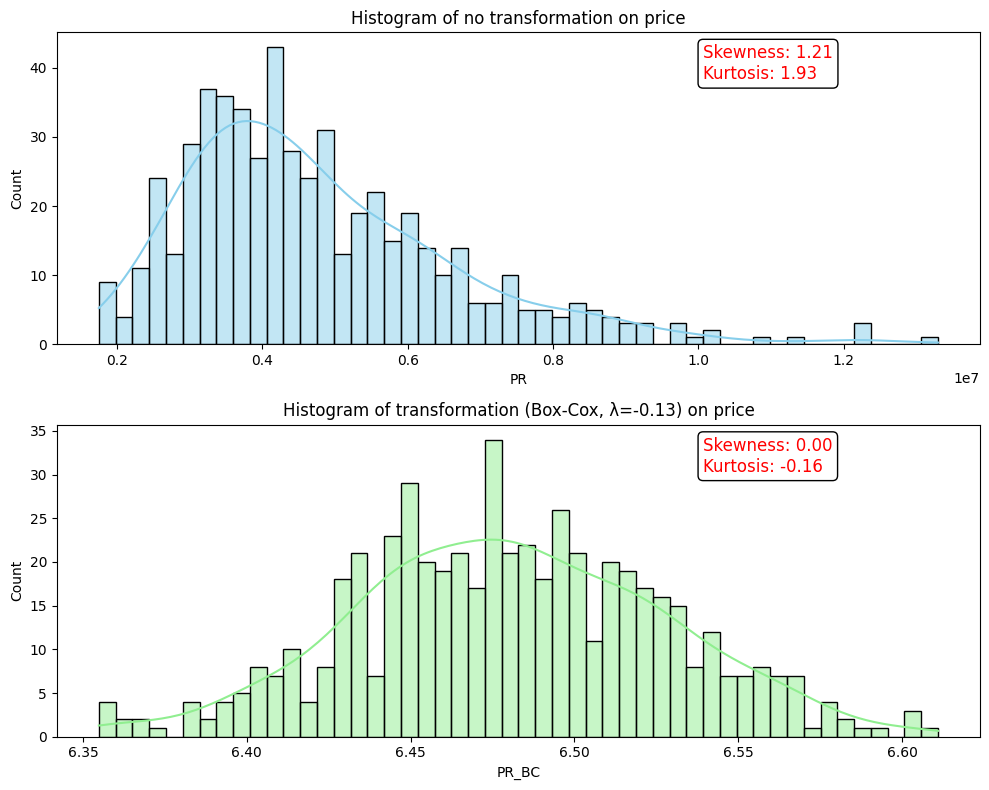

In [5]:
# Example: assume y_no_transform is your target variable (Series)
y_no_transform = df_encoded['PR']   # replace with your actual target column

# Apply Box-Cox transformation (requires strictly positive values)
y_boxcox = df_encoded['PR_BC']

# Compute skewness and kurtosis
skew_raw, kurt_raw = skew(y_no_transform), kurtosis(y_no_transform)
skew_box, kurt_box = skew(y_boxcox), kurtosis(y_boxcox)

# Create subplots (2 rows, 1 column)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# First row: raw y_no_transform
sns.histplot(y_no_transform, kde=True, ax=axes[0],bins=50, color="skyblue")
axes[0].set_title("Histogram of no transformation on price")
axes[0].annotate(f"Skewness: {skew_raw:.2f}\nKurtosis: {kurt_raw:.2f}",
                 xy=(0.70, 0.85), xycoords="axes fraction",
                 fontsize=12, color="red",  # <-- text color red
                 bbox=dict(boxstyle="round", fc="white", ec="black"))

# Second row: Box-Cox transformed y
sns.histplot(y_boxcox, kde=True, ax=axes[1],bins=50, color="lightgreen")
axes[1].set_title(f"Histogram of transformation (Box-Cox, λ={fitted_lambda:.2f}) on price")
axes[1].annotate(f"Skewness: {skew_box:.2f}\nKurtosis: {kurt_box:.2f}",
                 xy=(0.70, 0.85), xycoords="axes fraction",
                 fontsize=12, color="red",  # <-- text color red
                 bbox=dict(boxstyle="round", fc="white", ec="black"))

plt.tight_layout()
plt.show()

#### Qus: Is it possible to implement Ordinary Least Squares (OLS) based residual analyses and outlier detection methods in ridge regression using its hat matrix without modification ?

No, standard Ordinary Least Squares (OLS) based residual analyses and outlier detection methods are not directly applicable to ridge regression using its hat matrix without modification. This is because ridge regression introduces bias to the coefficients to handle multicollinearity, fundamentally changing the properties of the residuals and the hat matrix compared to OLS.

For OLS:

$H=X(X'X)^{-1}X'$

For Ridge:

$H_k=X(X'X+kI)^{-1}X'$

This $H_k$ is still a projection matrix, but not idempotent (i.e., $H_k^2\neq H_k$). Many OLS diagnostics that rely on **idempotency** (like exact variance of residuals) are approximate in ridge.

#### Using modified diagnostics designed:

Performing outlier and influential observation detection in ridge regression requires using modified diagnostics designed to account for the bias introduced by the penalty term ($k$). Standard OLS diagnostics are not suitable because they rely on assumptions of unbiasedness and specific variance properties that do not hold in ridge regression.

#### Modified Diagnostic Methods for Ridge Regression

1. Modified Cook's Distance $D_{k}$

Cook’s Distance is a diagnostic measure in regression analysis. It tells us how much the fitted regression model would change if a particular observation were removed. In other words: it combines residual size (how unusual the response is) and leverage (how unusual the predictor values are). 

Large Cook’s D values indicate influential points — observations that strongly affect the regression coefficients

Formula for Cook’s D (OLS):

For observation i:

$D_i=\frac{(\hat {\beta }_{(i)}-\hat {\beta })'X'X(\hat {\beta }_{(i)}-\hat {\beta })}{p\cdot MSE}$

Where:
- $\hat {\beta }$ = estimated coefficients using all data
- $\hat {\beta }_{(i)}$ = estimated coefficients with the i-th observation removed
- $X'X$ = information matrix from predictors
- $p$ = number of predictors (including intercept)
- $MSE$ = mean squared error of the regression

Modified Cook's distance for the regression coefficients is a generalization of the OLS formula:

$D_{k,i}=\frac{(\hat {\beta }_{(i)}-\hat {\beta })^T(X'X+kI)(\hat {\beta }_{(i)}-\hat {\beta })}{p\cdot \hat {\sigma }^2}$   --------- ($i$)

Eqn ($i$) can be expressed in terms of the modified leverage $h_{k,ii}$, the $i^th$ diagonal element of $H_{k}$ and the residual $e_{i}$

$D_{k,i}=\frac{e_{i}^{2}h_{k,ii}}{p\^{\sigma }^{2}(1-h_{k,ii})^{2}}$

Cutoff Values Unlike OLS, there is no single fixed thumb rule for the cutoff value due to the bias introduced by $k$.

**Remember: thresholds like $D_i>1$ are heuristics in ridge — use them comparatively, not as strict cutoffs.**

#### Modified DFFITS in Ridge Regression:

DFFITS (Difference in Fits) for ridge regression measures how much an observation's own fitted value changes when it is removed from the model.

The formula is a modification of the OLS DFFITS:

$\mathrm{DFFITS_{\mathnormal{k,i}}}=\frac{\hat {y}_i-\hat {y}_{(i)}}{\hat {\sigma }_{(i)}\sqrt{h_{k,ii}}}$

Where:
- $\hat {y}_i$: the fitted value for observation i in the full ridge regression model.
- $\hat {y}_{(i)}$: the fitted value for observation i when that observation is deleted from the model.
- $\hat {\sigma }_{(i)}$: the error standard deviation estimated without the i-th observation.
- $h_{k,ii}$: the leverage of observation i from the ridge hat matrix H$_k.

Cutoff Values
A common guideline is to flag observations where the absolute value of

$\mathrm{DFFITS_{\mathnormal{k,i}}}>2\times \sqrt{\frac{p+1}{n}}$

This threshold should be treated as a flexible guideline rather than a strict rule, especially in the ridge regression context.

#### Modified DFBETAs
DFBETAs measure the change in each specific regression coefficient j when the i-th observation is deleted.

$\mathrm{DFBETAS_{\mathnormal{k,i,j}}}=\frac{\hat {\beta }_j-\hat {\beta }_{j(i)}}{\hat {\sigma }_{(i)}\sqrt{(X'X+kI)_{jj}^{-1}}}$

Where:

- $\hat {\beta }_j$: coefficient $j$ estimated with all observations.
- $\hat {\beta }_{j(i)}$: coefficient $j$ estimated with the i-th observation removed.
- $\hat {\sigma }_{(i)}$: error standard deviation estimated without the $i-th$ observation.
- $(X'X+kI)_{jj}^{-1}$: the $j-th$ diagonal element of the ridge covariance matrix.

Cutoff Values:

Observations are typically considered influential if the absolute value of

$\mathrm{DFBETAS_{\mathnormal{k,i,j}}}>\frac{2}{\sqrt{n}}\quad \mathrm{or}\quad \frac{2}{\sqrt{\mathrm{effective\  degrees\  of\  freedom}}}$

- This threshold is a rule of thumb, not a strict cutoff.
- The determination depends heavily on the context of the dataset and the chosen ridge penalty parameter $k$.
- Larger sample sizes (higher $n$) make the cutoff smaller, meaning stricter detection of influential points.
- Using effective degrees of freedom (trace of the ridge hat matrix) instead of raw $n$ can be more appropriate in ridge regression, since shrinkage reduces model complexity.


In [6]:
ridge_penalty_param = [0.000444, 0.01, 0.1, 0.2, 0.43, 0.44, 0.45, 0.5, 0.6, 0.7, 0.8, 1.589, 1.848, 1.879, 1.883, 5.0, 6.0, 7.0]
modified_optimum_k_concidered_all = [0.000444, 0.01, 0.1, 0.45, 0.8, 1.79975, 6.0,7.0]

In [7]:
def ridge_diagnostics(X_regressor, y_dependent, k_values):
    """
    Compute ridge hat matrix, residuals, and Cook's Distance analogue for each k.

    Parameters
    ----------
    results : dict
        Dictionary keyed by k, with values containing:
        - Hk : ridge hat matrix
        - residuals : residual vector
        - cooksD : array of Cook's Distance analogue for each observation
    """
    X__ = np.asarray(X_regressor)
    y__ = np.asarray(y_dependent).flatten()  # Ensure y__ is a 1D array
    n, p = X_regressor.shape
    XtX = X__.T @ X__
    Xty = X__.T @ y__
    I = np.eye(p)
    results = {}

    for k in k_values:
        # Ridge coefficients
        beta_ridge = np.linalg.inv(XtX + (k * I)) @ Xty        
        XtX_inv_k = np.linalg.pinv(XtX + (k * I))
        L = XtX_inv_k @ X__.T
        # Hat matrix
        Hk = X__ @ L + X__ @ XtX_inv_k @ X__.T
        
        # Predictions and residuals
        y_hat = X__ @ beta_ridge
        residuals = y__ - y_hat.flatten()  # Ensure y_hat is also 1D
        
        # Effective degrees of freedom
        df_ridge = np.trace(Hk)
        
        # Variance estimate
        sigma2_ridge = (residuals @ residuals) / (n - df_ridge)
        
        # Cook's Distance analogue
        h_diag = np.diag(Hk)
        cooksD = (residuals**2 * h_diag) / (p * sigma2_ridge * (1 - h_diag)**2)
        
        results[k] = {
            "Hk": Hk,
            "residuals": residuals,
            "cooksD": cooksD
        }
    return results

In [8]:
InfuanceData_one_line = ridge_diagnostics(X_regressor = X_single_sol, 
                  y_dependent = y_single_sol, 
                  k_values = modified_optimum_k_concidered_all, 
                 )

InfuanceData_one_line_bc = ridge_diagnostics(X_regressor = X_single_sol_bc, 
                  y_dependent = y_single_sol_bc, 
                  k_values = modified_optimum_k_concidered_all, 
                 )

InfuanceData_two_line = ridge_diagnostics(X_regressor = X_two_sol, 
                  y_dependent = y_two_sol, 
                  k_values = modified_optimum_k_concidered_all, 
                 )

InfuanceData_two_line_bc = ridge_diagnostics(X_regressor = X_two_sol_bc, 
                  y_dependent = y_two_sol_bc, 
                  k_values = modified_optimum_k_concidered_all, 
                 )

In [9]:
def ridge_hat_matrix(X_regressor: np.ndarray, k: float) -> np.ndarray:
    """
    Compute the ridge regression hat matrix H_k = X (X'X + kI)^(-1) X'.
    Returns
    -------
    H_k : np.ndarray
        Hat matrix of shape (n, n).
    """
    # Ensure X is numpy array
    X = np.asarray(X_regressor)
    
    # Dimensions
    n, p = X.shape
    
    # Compute (X'X + kI)^(-1)
    XtX = X.T @ X
    ridge_term = XtX + k * np.eye(p)
    ridge_inv = np.linalg.inv(ridge_term)
    
    # Hat matrix
    H_k = X @ ridge_inv @ X.T
    return H_k

In [10]:
def ridge_diagnostics_to_dataframes(diagnostics):
    """
    Convert ridge diagnostics dictionary into pandas DataFrames
    for Cook's D, DFFITS, and DFBETAs.

    Parameters
    ----------
    diagnostics : dict
        Output from ridge_influence_diagnostics(), keyed by k values.

    Returns
    -------
    cooksD_df : pd.DataFrame
        Cook's Distance values, rows = observations, cols = k values.
    dffits_df : pd.DataFrame
        DFFITS values, rows = observations, cols = k values.
    dfbetas_dict : dict of pd.DataFrame
        DFBETAs values, one DataFrame per k value
        (rows = observations, cols = predictors).
    """
    cooksD_df = pd.DataFrame()
    dffits_df = pd.DataFrame()
    dfbetas_dict = {}

    for k, metrics in diagnostics.items():
        # Cook's D
        cooksD_df[k] = metrics["cooksD"]

        # DFFITS
        dffits_df[k] = metrics["dffits"]

        # DFBETAs (matrix: n_samples x n_features)
        dfbetas_dict[k] = pd.DataFrame(metrics["dfbetas"],
                                       columns=[f"beta_{j}" for j in range(metrics["dfbetas"].shape[1])])

    return cooksD_df, dffits_df, dfbetas_dict

In [11]:
type(y_single_sol),type(X_single_sol)

(pandas.core.frame.DataFrame, pandas.core.frame.DataFrame)

In [12]:
def ridge_influence_diagnostics(X_regressor: pd.DataFrame, 
                                y_dependent: pd.DataFrame, 
                                k_values: list):
    """
    Compute ridge hat matrix, residuals, Cook's D, DFBETAs, and DFFITS for each k.

    Parameters
    ----------
    X_regressor : pandas.DataFrame (n_samples, n_features)
        Design matrix of predictors.
    y_dependent : pandas.DataFrame (n_samples, 1)
        Response vector.
    k_values : list of floats
        List of ridge penalty values (lambda/k).

    Returns
    -------
    results : dict
        Dictionary keyed by k, with values containing:
        - Hk : ridge hat matrix
        - residuals : residual vector
        - cooksD : Cook's Distance analogue
        - dfbetas : array (n_samples, n_features) of DFBETAs
        - dffits : array of DFFITS values
    """
    # Convert inputs to numpy arrays
    X = X_regressor.values
    y = y_dependent.values.ravel()

    n, p = X.shape
    XtX = X.T @ X
    Xty = X.T @ y

    results = {}

    for k in k_values:
        k = float(k)   # ensure float key
        # Ridge coefficients
        beta_ridge = np.linalg.inv(XtX + k * np.eye(p)) @ Xty
        
        # Hat matrix
        Hk = X @ np.linalg.inv(XtX + k * np.eye(p)) @ X.T
        
        # Predictions and residuals
        y_hat = X @ beta_ridge
        residuals = y - y_hat
        
        # Effective degrees of freedom
        df_ridge = np.trace(Hk)
        
        # Variance estimate
        sigma2_ridge = (residuals @ residuals) / (n - df_ridge)
        sigma_ridge = np.sqrt(sigma2_ridge)
        
        # Diagonal of hat matrix
        h_diag = np.diag(Hk)
        
        # Cook's Distance analogue
        cooksD = (residuals**2 * h_diag) / (p * sigma2_ridge * (1 - h_diag)**2)
        
        # DFFITS
        dffits = (residuals / (sigma_ridge * np.sqrt(1 - h_diag))) * np.sqrt(h_diag / (1 - h_diag))
        
        # DFBETAs (approximate)
        cov_ridge = np.linalg.inv(XtX + k * np.eye(p))
        dfbetas = np.zeros((n, p))
        for i in range(n):
            for j in range(p):
                dfbetas[i, j] = (residuals[i] / (sigma_ridge * np.sqrt(1 - h_diag[i]))) * \
                                (X[i, j] / np.sqrt(cov_ridge[j, j]))
        
        results[k] = {
            "Hk": Hk,
            "residuals": residuals,
            "cooksD": cooksD,
            "dffits": dffits,
            "dfbetas": dfbetas
        }

    return results

In [13]:
diagnostics = ridge_influence_diagnostics(X_regressor = X_single_sol, 
                  y_dependent = y_single_sol, 
                  k_values = modified_optimum_k_concidered_all)
print(diagnostics.keys())
# Replace 1.0 with a valid key from modified_optimum_k_concidered_all, e.g., 174.614
#valid_k = modified_optimum_k_concidered_all[0]  # Use the first value in modified_optimum_k_concidered_all as an example
cooksD_df, dffits_df, dfbetas_dict = ridge_diagnostics_to_dataframes(diagnostics)


dict_keys([0.000444, 0.01, 0.1, 0.45, 0.8, 1.79975, 6.0, 7.0])


#### Cutoff value of CooksD

$D_i > 1$ Not strict cutoff.

In [14]:
Di = 1
for col in cooksD_df.columns:
    print(f"\nResults for column: {col}")    
    # Filter rows where values > 1
    filtered = cooksD_df[cooksD_df[col] > Di]    
    if filtered.empty:
        print("Not found")
    else:
        print("CooksIndices:", filtered.index.tolist())


Results for column: 0.000444
Not found

Results for column: 0.01
Not found

Results for column: 0.1
Not found

Results for column: 0.45
Not found

Results for column: 0.8
Not found

Results for column: 1.79975
Not found

Results for column: 6.0
Not found

Results for column: 7.0
Not found


In [15]:
n,p = X_single_sol.shape
dffits_cutoff = 2*np.sqrt((p+1)/n)

for col in dffits_df.columns:
    print(f"\nResults for column: {col}")    
    # Filter rows where values > 1
    filtered = dffits_df[dffits_df[col] > dffits_cutoff]    
    if filtered.empty:
        print("Not found")
    else:
        print("DFFITS  Indices:", filtered.index.tolist())


Results for column: 0.000444
DFFITS  Indices: [0, 1, 2, 3, 4, 5, 7, 8, 11, 13, 14, 15, 18, 20, 21, 22, 27, 31, 33, 36, 38, 48, 87, 157]

Results for column: 0.01
DFFITS  Indices: [0, 1, 2, 3, 4, 5, 7, 8, 11, 13, 14, 15, 18, 20, 21, 22, 27, 31, 33, 36, 38, 48, 87, 157]

Results for column: 0.1
DFFITS  Indices: [0, 1, 2, 3, 4, 5, 7, 8, 11, 13, 14, 15, 18, 20, 21, 22, 27, 31, 33, 36, 38, 48, 87, 157]

Results for column: 0.45
DFFITS  Indices: [0, 1, 2, 3, 4, 5, 7, 8, 11, 13, 14, 15, 18, 20, 21, 22, 27, 31, 33, 36, 38, 48, 87, 157]

Results for column: 0.8
DFFITS  Indices: [0, 1, 2, 3, 4, 5, 7, 8, 11, 13, 14, 15, 18, 20, 21, 22, 27, 31, 33, 36, 38, 48, 87, 157]

Results for column: 1.79975
DFFITS  Indices: [0, 1, 2, 3, 4, 5, 7, 8, 11, 13, 14, 15, 18, 20, 21, 22, 27, 31, 33, 36, 38, 48, 87, 157]

Results for column: 6.0
DFFITS  Indices: [0, 1, 2, 3, 4, 5, 7, 8, 11, 13, 14, 15, 18, 20, 22, 27, 31, 33, 38, 48, 87, 157]

Results for column: 7.0
DFFITS  Indices: [0, 1, 2, 3, 4, 5, 7, 8, 11, 13

In [16]:
def __cooks_dist_line(factor,nparams_,leverage_):
    """
    Helper function for plotting Cook's distance curves
    """
    p = nparams_
    formula = lambda x: np.sqrt((factor * p * (1 - x)) / x)
    x__ = np.linspace(0.001, max(leverage_), 50)
    y__ = formula(x__)
    return x__, y__
    
def residuals_vs_leverage_plot(X_regressor: pd.DataFrame, 
                               y_dependent: pd.DataFrame, 
                               k_list: list, 
                               cooks_distance: pd.DataFrame,
                               cooks_threshold="baseR",
                               high_leverage_threshold=False,
                               model_name = "Ridge Regression leverage plot"):
    """
    Plot Residuals vs. Leverage for multiple ridge penalty values (k_list).
    Creates a subplot grid with 4 rows × 2 columns (8 plots).
    """
    # Convert inputs to numpy arrays
    X = X_regressor.values
    y = y_dependent.values.ravel()
    n, p = X.shape
    nparams = p
    nresids = y.shape[0]

    fig, axes = plt.subplots(4, 2, figsize=(14, 20))
    axes = axes.flatten()

    for idx, k in enumerate(k_list):
        ax = axes[idx]
        # Hat matrix for ridge
        H_k = ridge_hat_matrix(X_regressor=X, k=k)

        # Fitted values and residuals
        y_hat = H_k @ y.reshape(-1, 1)
        residuals = (y.reshape(-1, 1) - y_hat).flatten()

        # Leverage = diagonal of hat matrix
        leverage = np.diag(H_k)

        # Scatter plot
        ax.scatter(leverage, residuals, alpha=0.6, color="blue")
        sns.regplot(x=leverage, y=residuals, scatter=False, ci=False,
                    lowess=True, line_kws={"color": "red", "lw": 1, "alpha": 0.8}, ax=ax)

        if k not in cooks_distance.columns:
            raise ValueError(f"Missing required columns: {k}")

        # Annotate top 3 Cook’s D points
        leverage_top_3 = np.flip(np.argsort(cooks_distance[k]), 0)[:3]
        for i in leverage_top_3:
            ax.annotate(i, xy=(leverage[i], residuals[i]), color="C3")

        # Threshold factors
        if cooks_threshold == "baseR" or cooks_threshold is None:
            factors = [1, 0.5]
        elif cooks_threshold == "convention":
            factors = [4 / nresids]
        elif cooks_threshold == "dof":
            factors = [4 / (nresids - nparams)]
        else:
            raise ValueError("threshold_method must be one of: 'convention', 'dof', or 'baseR'")

        # Horizontal line at 0
        ax.axhline(0, ls="dotted", color="black", lw=1.25)
        ax.set_xlim(0, max(leverage) + 0.01)
        ax.set_ylim(min(residuals) - 0.1, max(residuals) + 0.1)
        ax.set_xlabel("Leverage")
        ax.set_ylabel("Residuals")
        ax.set_title(f"{model_name} (k={k})")
        ax.grid(True)
        
    plt.tight_layout()
    plt.show()

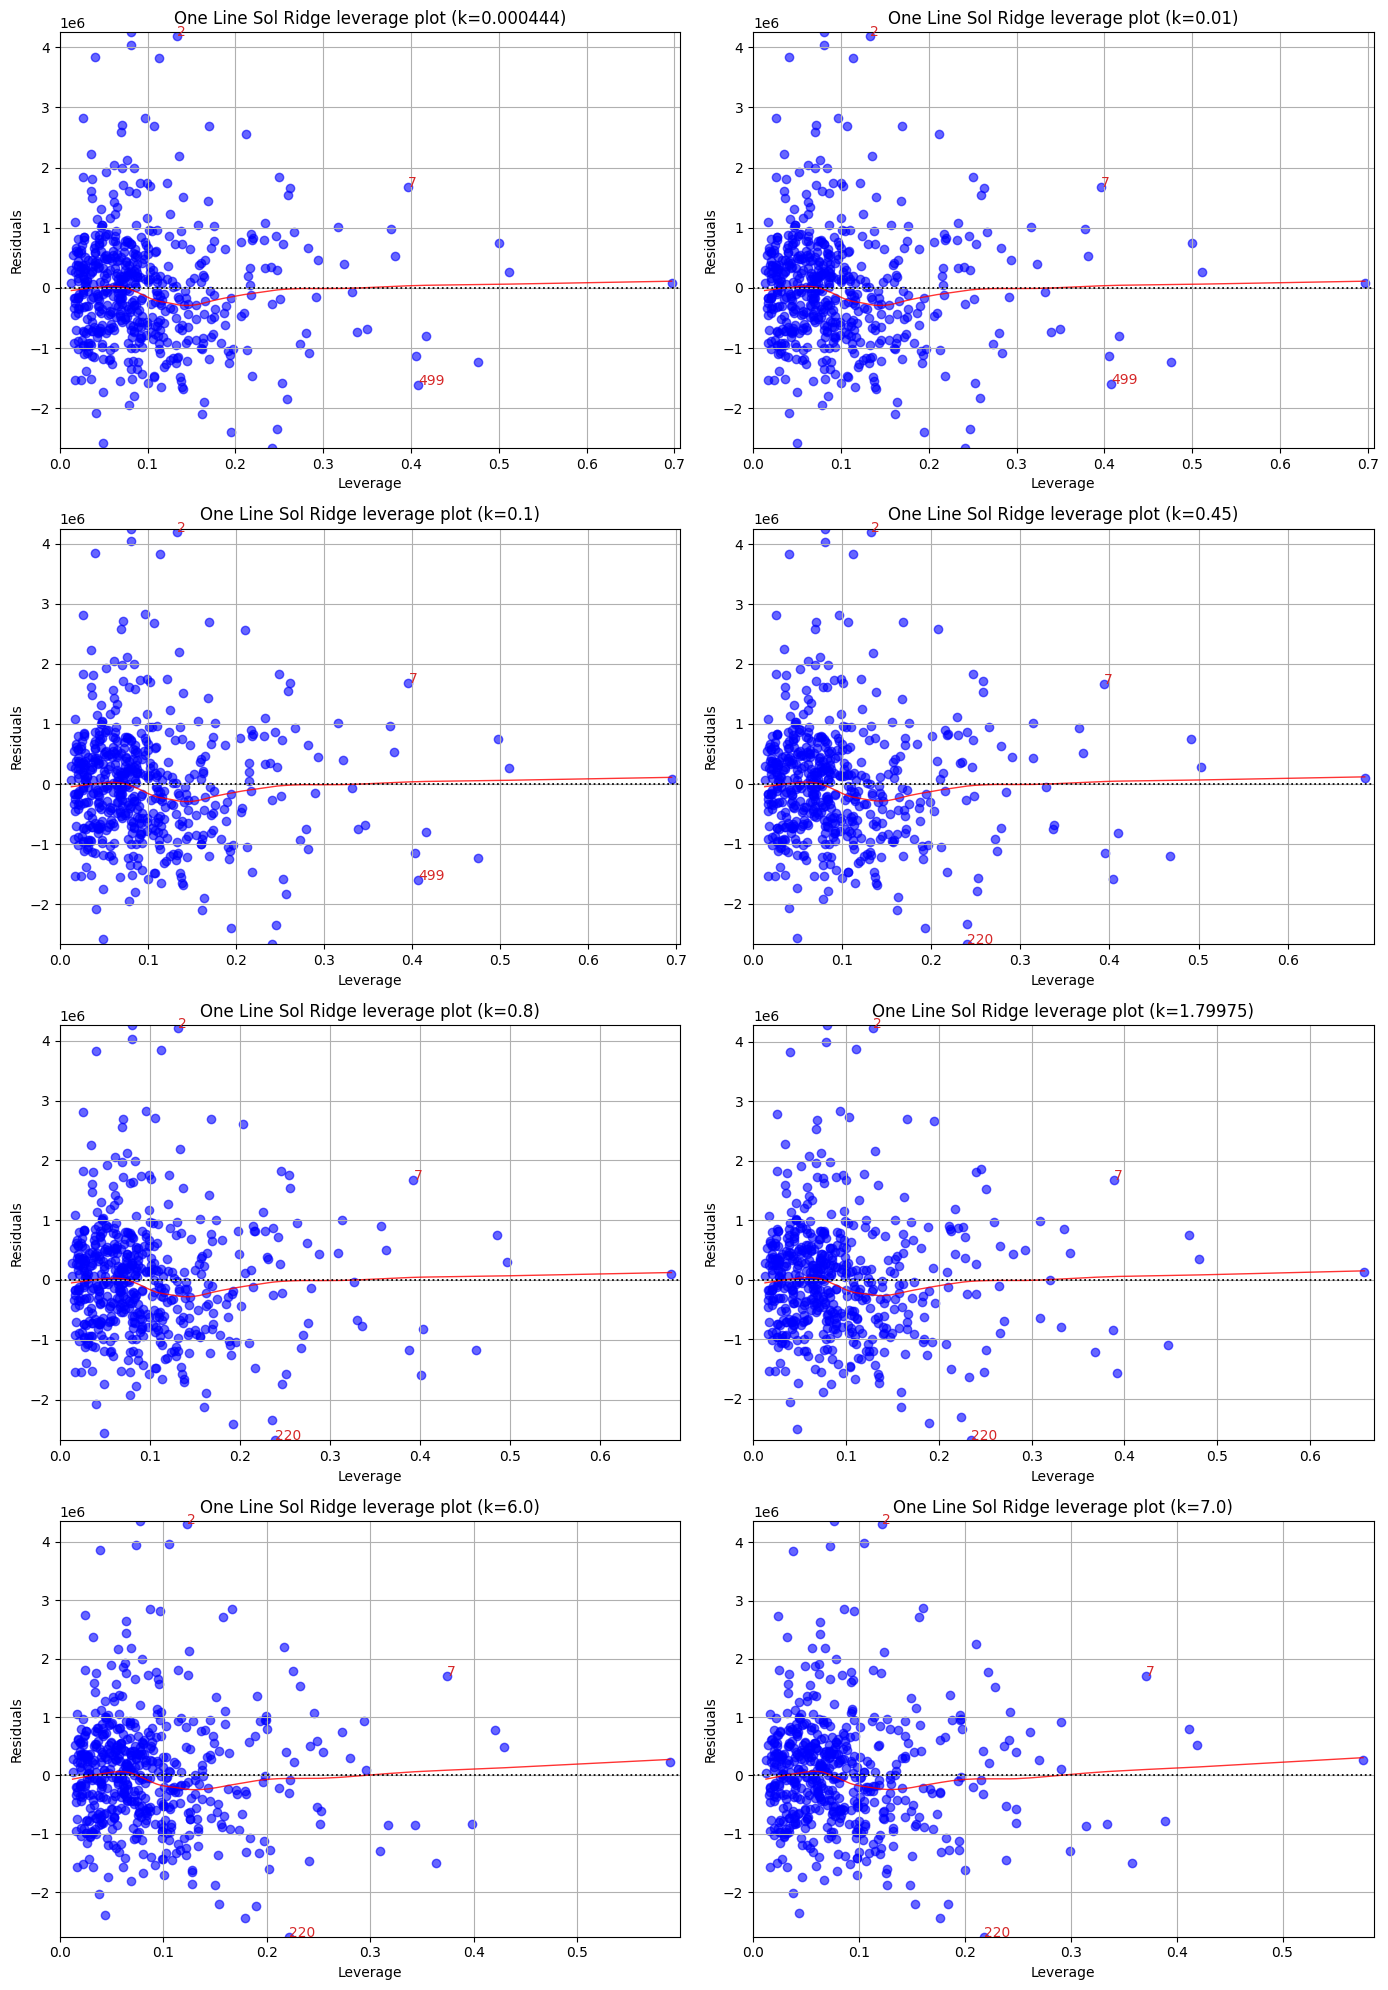

In [17]:

residuals_vs_leverage_plot(X_regressor = X_single_sol, 
                               y_dependent = y_single_sol, 
                               k_list = modified_optimum_k_concidered_all, 
                               cooks_distance = cooksD_df,
                               cooks_threshold="baseR",
                               high_leverage_threshold=False,
                               model_name = "One Line Sol Ridge leverage plot"
                               )

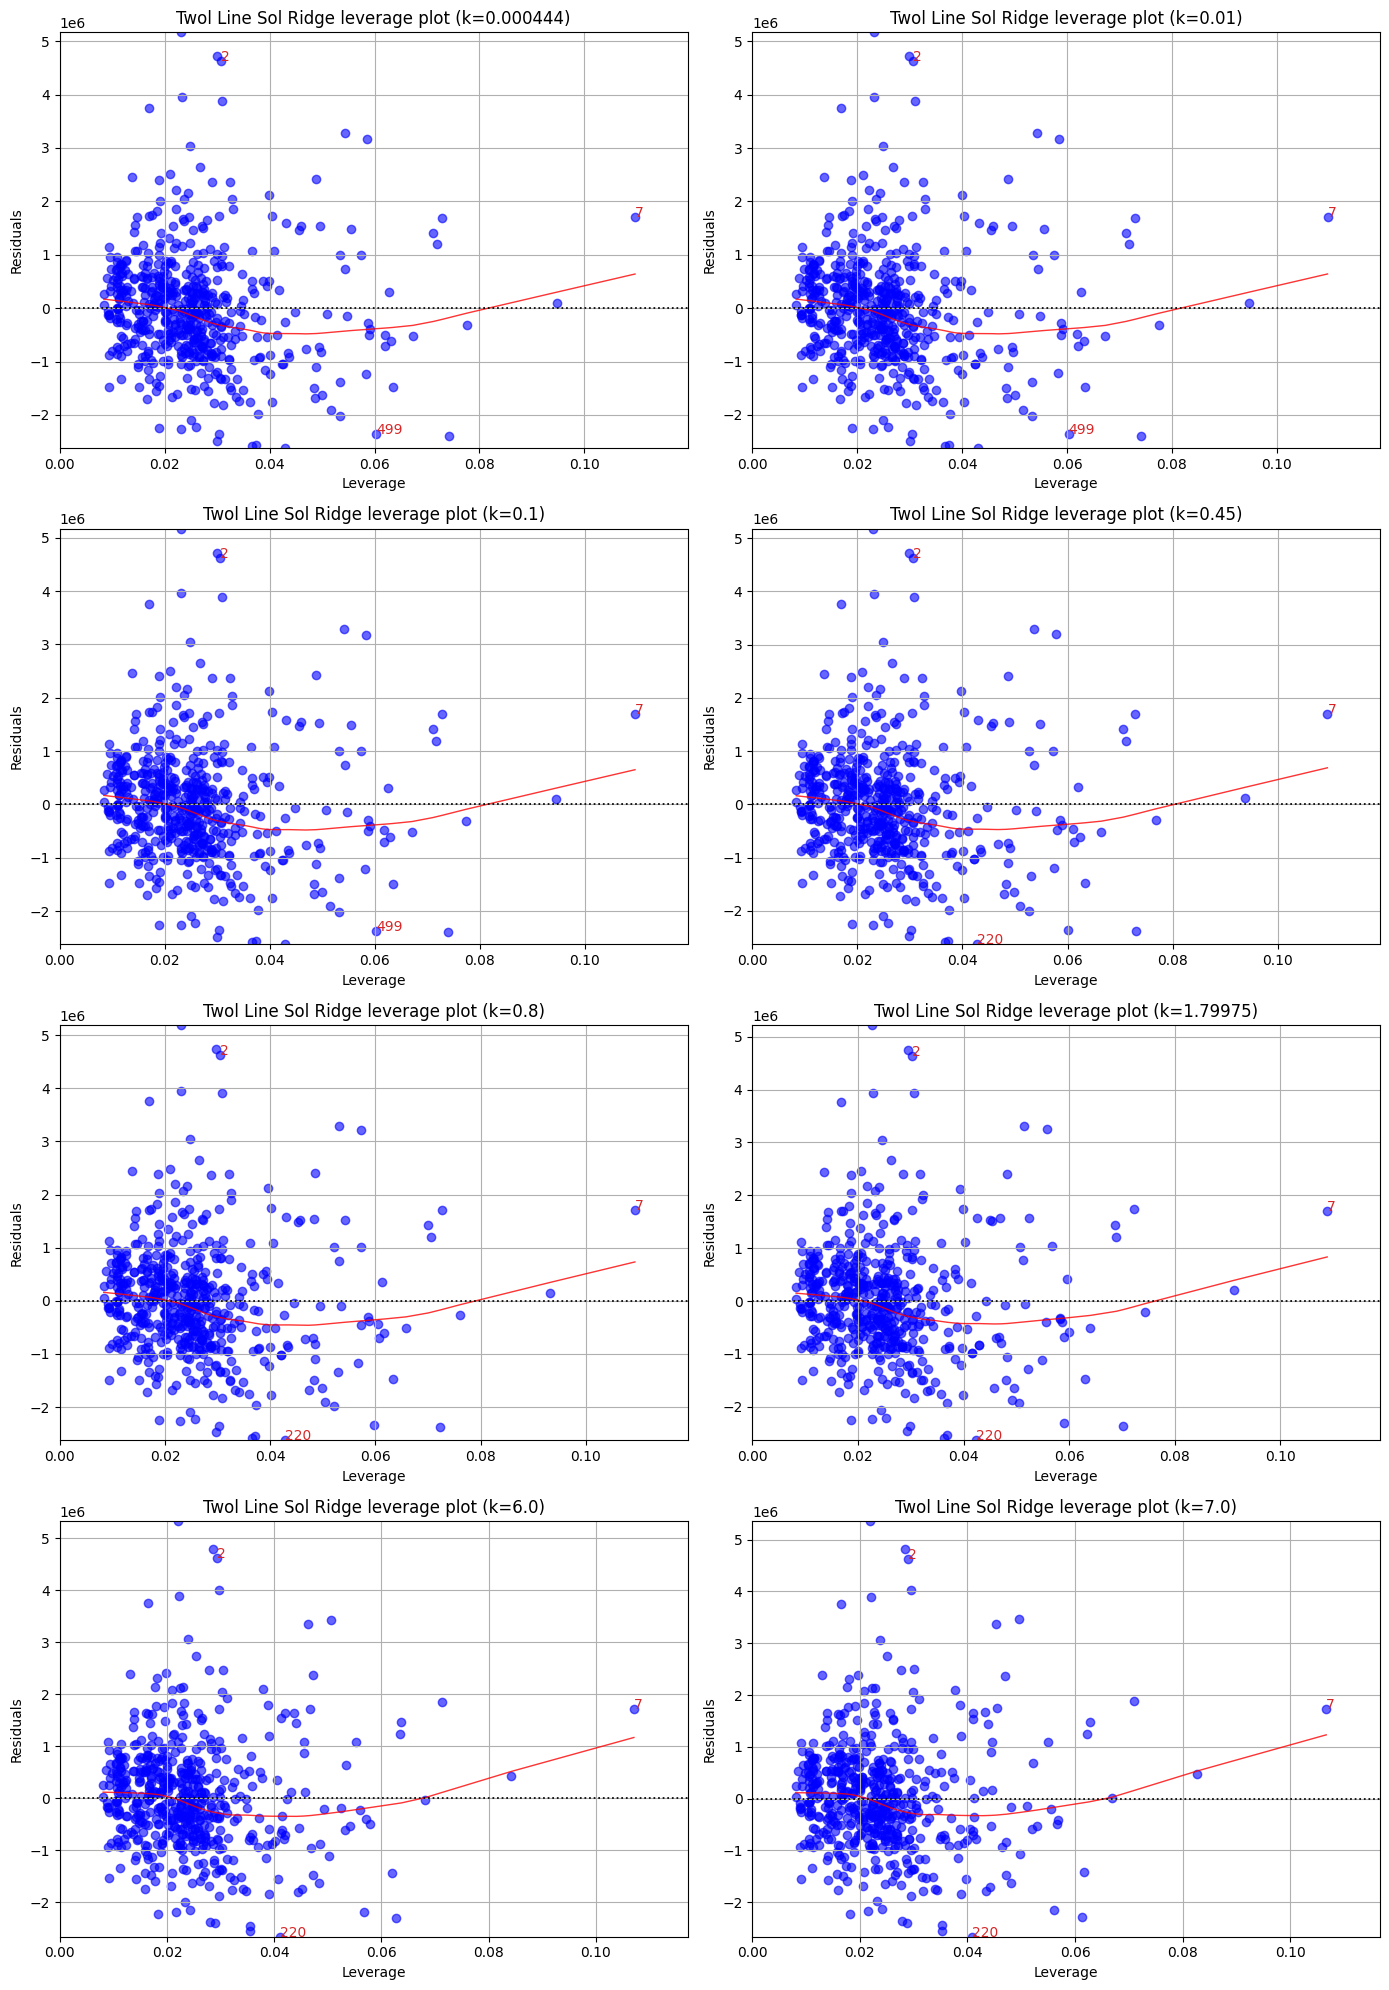

In [18]:

residuals_vs_leverage_plot(X_regressor = X_two_sol, 
                               y_dependent = y_two_sol, 
                               k_list = modified_optimum_k_concidered_all, 
                               cooks_distance = cooksD_df,
                               cooks_threshold="baseR",
                               high_leverage_threshold=False,
                               model_name = "Twol Line Sol Ridge leverage plot"
                               )

All figure explaine letter 😊
